In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

In [55]:
df= pd.read_csv('train.csv')

In [56]:
features = ['Pclass','Sex','Age','SibSp','Parch','Fare']
X = df[features].copy()
y = df['Survived']

print("Missing values")
print(X.isna().sum())
X['Age']=X['Age'].fillna(X['Age'].median())
print('Missing values after')
print(X.isna().sum())

X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

Missing values
Pclass      0
Sex         0
Age       177
SibSp       0
Parch       0
Fare        0
dtype: int64
Missing values after
Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64


In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: { X_test_scaled.shape[0]}")

Training samples: 712
Test samples: 179


In [58]:
param_grid = {
    'n_neighbors': list(range(1, 31, 2)),
    'metric': ['euclidean', 'manhattan']}

knn= KNeighborsClassifier()
grid_clf = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_clf.fit(X_train_scaled, y_train)
print(f"Best k: {grid_clf.best_params_['n_neighbors']}")
print(f"Best metric: {grid_clf.best_params_['metric']}")
best_model= grid_clf.best_estimator_
test_accuracy= grid_clf.score(X_test_scaled,y_test)
print(f"Test accuracy: {test_accuracy:.3f}")

Best k: 15
Best metric: manhattan
Test accuracy: 0.799


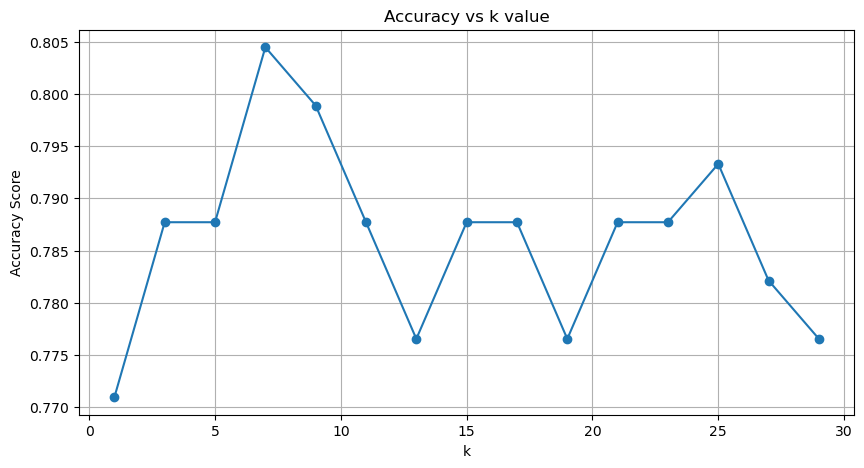

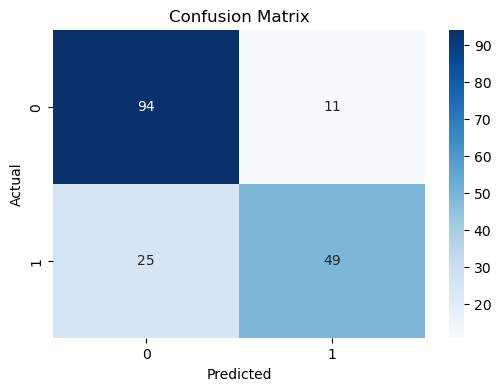

In [59]:
k_range = range(1, 31,2)
accuracies = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o')
plt.title('Accuracy vs k value')
plt.xlabel('k')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [60]:
joblib.dump(best_model, "titanic_knn_model.joblib")

['titanic_knn_model.joblib']